# Synthetic Map vs alphaCO-weighted Sum Test

For every galaxy and every CDD scale, computes:
- **Sum A**: `np.nansum(synth_map)` — total F770W flux in the synthetic filament map
- **Sum B**: `np.nansum(synth_map * alphaCO_reprojected)` — same map weighted pixel-by-pixel
  by the spatially resolved dynamic alphaCO (SL24 tag), reprojected to match the synthetic map

The ratio B/A is the **effective mean alphaCO felt by the filaments** at each scale.
If B/A varies with scale, the alphaCO weighting is contributing to scale-dependent mass offsets
in addition to any flux-level differences between CDD layers.

**Run order**: Cell 1 (config) → Cell 2 (loop + print) → Cell 3 (summary plot)


In [1]:
# =============================================================================
# Cell 1: Imports and paths
# =============================================================================
import os
import re
import warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from astropy.wcs import FITSFixedWarning
from reproject import reproject_interp

warnings.filterwarnings('ignore', category=FITSFixedWarning)

BASE_DIR       = Path(r"C:\Users\jhoffm72\Documents\FilPHANGS\Data")
ALPHACO_DIR    = BASE_DIR / "PHANGS_alphaCO_conversion_factor_maps"
ALPHACO_TAG    = "SL24"    # must match the tag used in the pipeline run
SCALES_ORDER   = [16, 32, 64, 128, 256]   # for consistent column ordering

# Galaxies to test: all folders that have a SyntheticMap sub-directory
galaxy_dirs = sorted(
    d for d in BASE_DIR.iterdir()
    if d.is_dir()
    and (d / "SyntheticMap").is_dir()
    and "F770W" in d.name
)
print(f"Found {len(galaxy_dirs)} galaxies with SyntheticMap folders:")
for g in galaxy_dirs:
    print(f"  {g.name}")

Found 17 galaxies with SyntheticMap folders:
  ngc0628_F770W
  ngc1087_F770W
  ngc1300_F770W
  ngc1365_F770W
  ngc1385_F770W
  ngc1433_F770W
  ngc1512_F770W
  ngc1566_F770W
  ngc2835_F770W
  ngc3351_F770W
  ngc3627_F770W
  ngc4254_F770W
  ngc4303_F770W
  ngc4321_F770W
  ngc4535_F770W
  ngc5068_F770W
  ngc7496_F770W


In [2]:
# =============================================================================
# Cell 2: Loop over galaxies and scales
# =============================================================================

def find_alphaCO(galaxy_label, alphaCO_dir, tag):
    """Return path to the alphaCO FITS for this galaxy and tag, or None."""
    galaxy = galaxy_label.split("_")[0].lower()
    for fname in os.listdir(alphaCO_dir):
        if galaxy in fname.lower() and tag.lower() in fname.lower():
            return alphaCO_dir / fname
    return None


def reproject_to_synth(alphaCO_path, synth_header, synth_shape):
    """Reproject the alphaCO map onto the synthetic map WCS grid."""
    with fits.open(alphaCO_path) as h:
        aco_data   = np.array(h[0].data, dtype=float)
        aco_header = h[0].header
    reprojected, _ = reproject_interp(
        (aco_data, aco_header), synth_header, shape_out=synth_shape
    )
    return reprojected   # NaNs where alphaCO has no coverage


# results[galaxy_name][scale_str] = (sum_synth, sum_weighted, ratio)
results = {}

for gal_dir in galaxy_dirs:
    gal_name  = gal_dir.name
    synth_dir = gal_dir / "SyntheticMap"

    aco_path = find_alphaCO(gal_name, ALPHACO_DIR, ALPHACO_TAG)
    if aco_path is None:
        print(f"  [{gal_name}] no alphaCO file found for tag '{ALPHACO_TAG}' -- skipping")
        continue

    print(f"\n{gal_name}  (alphaCO: {aco_path.name})")
    print(f"  {'Scale':>5}  {'sum(synth)':>14}  {'sum(synth*aCO)':>16}  {'ratio B/A':>10}")

    results[gal_name] = {}
    aco_reproj_cache = {}   # keyed by synth shape so we only reproject once per image size

    for synth_file in sorted(synth_dir.glob("*_SyntheticMap_*.fits")):
        m = re.search(r'CDDss(\d+)pc', synth_file.name)
        if not m:
            continue
        scale_str = m.group(1)

        with fits.open(synth_file) as h:
            synth_data   = np.array(h[0].data, dtype=float)
            synth_header = h[0].header

        # Reproject alphaCO once per unique synth shape
        shape_key = synth_data.shape
        if shape_key not in aco_reproj_cache:
            try:
                aco_reproj_cache[shape_key] = reproject_to_synth(
                    aco_path, synth_header, synth_data.shape
                )
            except Exception as e:
                print(f"    reprojection error: {e}")
                aco_reproj_cache[shape_key] = None

        aco_map = aco_reproj_cache[shape_key]
        if aco_map is None:
            continue

        sum_synth    = float(np.nansum(synth_data))
        sum_weighted = float(np.nansum(synth_data * aco_map))
        ratio        = sum_weighted / sum_synth if sum_synth != 0 else np.nan

        print(f"  {scale_str:>5}pc  {sum_synth:>14.4e}  {sum_weighted:>16.4e}  {ratio:>10.4f}")
        results[gal_name][scale_str] = (sum_synth, sum_weighted, ratio)

print("\nDone.")


ngc0628_F770W  (alphaCO: NGC0628_alphaCO21_SL24_MUSEGPR.fits)
  Scale      sum(synth)    sum(synth*aCO)   ratio B/A
   0016pc      3.9366e+05        2.0836e+06      5.2928
   0032pc      4.4975e+05        2.4446e+06      5.4355
   0064pc      4.7226e+05        2.5999e+06      5.5054
   0128pc      4.8903e+05        2.7380e+06      5.5989
   0256pc      4.3567e+05        2.4740e+06      5.6786

ngc1087_F770W  (alphaCO: NGC1087_alphaCO21_SL24_MUSEGPR.fits)
  Scale      sum(synth)    sum(synth*aCO)   ratio B/A
   0032pc      1.3556e+05        1.2245e+06      9.0332
   0064pc      1.3231e+05        1.1439e+06      8.6456
   0128pc      1.8665e+05        1.4105e+06      7.5567
   0256pc      1.8427e+05        1.3464e+06      7.3070

ngc1300_F770W  (alphaCO: NGC1300_alphaCO21_SL24_MUSEGPR.fits)
  Scale      sum(synth)    sum(synth*aCO)   ratio B/A
   0032pc      1.2592e+05        7.8194e+05      6.2101
   0064pc      1.0732e+05        6.5828e+05      6.1339
   0128pc      1.0968e+05        

C:\Users\jhoffm72\AppData\Local\Temp\ipykernel_23360\4013862486.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=7, ncol=2)


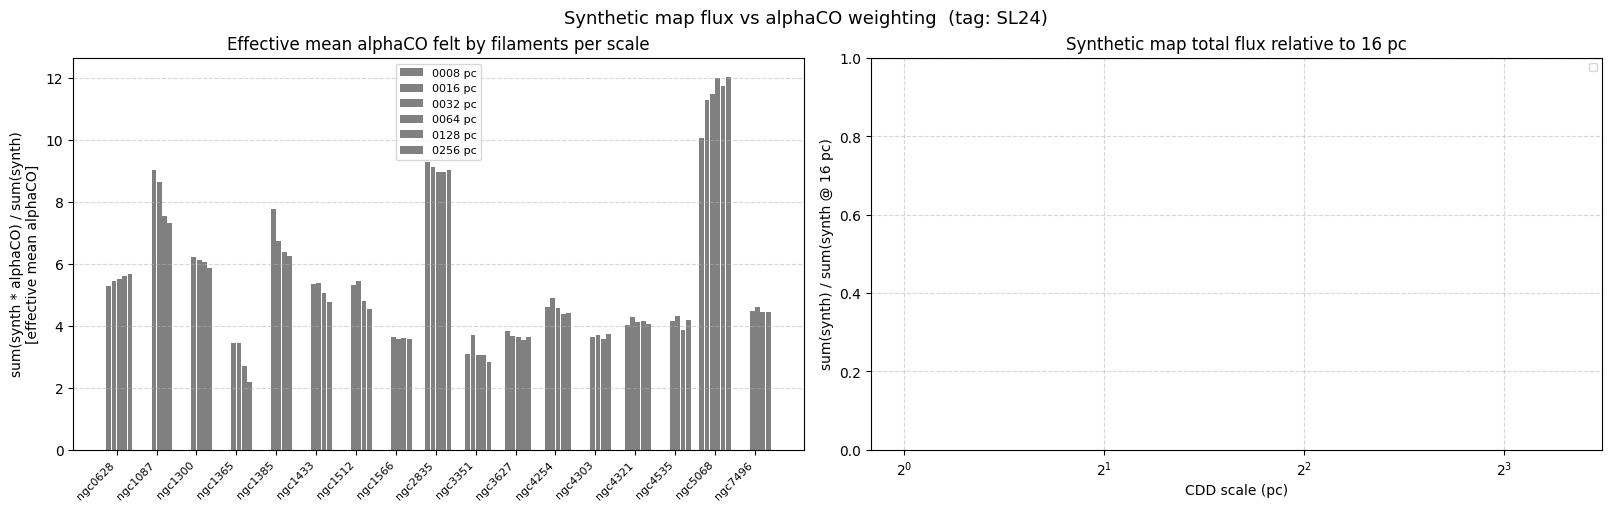

Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\SynthVsAlphaCO_SL24.png


In [3]:
# =============================================================================
# Cell 3: Summary plot -- effective mean alphaCO per scale per galaxy
# Ratio B/A = sum(synth * alphaCO) / sum(synth) = mean alphaCO felt by filaments
# =============================================================================
SCALE_COLORS = {
    "16":  "#e41a1c",
    "32":  "#ff7f00",
    "64":  "#4daf4a",
    "128": "#377eb8",
    "256": "#984ea3",
}

# -- Panel 1: ratio B/A per galaxy per scale (grouped bar) --------------------
gals = [g for g in results if results[g]]
scales_present = sorted(
    {s for g in gals for s in results[g]}, key=float
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

ax = axes[0]
x = np.arange(len(gals))
width = 0.8 / max(len(scales_present), 1)
for i, s in enumerate(scales_present):
    ratios = [results[g][s][2] if s in results[g] else np.nan for g in gals]
    offset = (i - len(scales_present) / 2 + 0.5) * width
    ax.bar(x + offset, ratios, width=width * 0.9,
           color=SCALE_COLORS.get(s, "gray"), label=f"{s} pc")
ax.set_xticks(x)
ax.set_xticklabels([g.replace("_F770W", "") for g in gals], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("sum(synth * alphaCO) / sum(synth)\n[effective mean alphaCO]")
ax.set_title("Effective mean alphaCO felt by filaments per scale")
ax.legend(fontsize=8)
ax.grid(True, ls="--", alpha=0.5, axis="y")

# -- Panel 2: sum(synth) per scale, normalised to 16 pc -----------------------
ax2 = axes[1]
for g in gals:
    ref = results[g].get("16", (np.nan,))[0]
    if ref and ref > 0:
        xs, ys = [], []
        for s in scales_present:
            if s in results[g]:
                xs.append(float(s))
                ys.append(results[g][s][0] / ref)
        ax2.plot(xs, ys, marker="o", lw=1.5, alpha=0.7,
                 label=g.replace("_F770W", ""))
ax2.axhline(1.0, color="k", ls="--", lw=0.8)
ax2.set_xscale("log", base=2)
ax2.set_xlabel("CDD scale (pc)")
ax2.set_ylabel("sum(synth) / sum(synth @ 16 pc)")
ax2.set_title("Synthetic map total flux relative to 16 pc")
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, ls="--", alpha=0.5)

fig.suptitle(f"Synthetic map flux vs alphaCO weighting  (tag: {ALPHACO_TAG})",
             fontsize=13)

out = BASE_DIR / "Figures" / f"SynthVsAlphaCO_{ALPHACO_TAG}.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {out}")


ngc0628_F770W
  Scale      sum(synth)    sum(mol_mass)     ratio M/F
   0016pc      3.9366e+05       7.9236e+07    2.0128e+02
   0032pc      4.4975e+05       6.7254e+07    1.4954e+02
   0064pc      4.7226e+05       6.5910e+07    1.3956e+02
   0128pc      4.8903e+05       4.9173e+07    1.0055e+02
   0256pc      4.3567e+05       2.6431e+07    6.0667e+01

ngc1087_F770W
  Scale      sum(synth)    sum(mol_mass)     ratio M/F
   0032pc      1.3556e+05       8.5463e+07    6.3046e+02
   0064pc      1.3231e+05       9.1371e+07    6.9059e+02
   0128pc      1.8665e+05       1.8881e+08    1.0116e+03
   0256pc      1.8427e+05       1.4414e+08    7.8225e+02

ngc1300_F770W
  Scale      sum(synth)    sum(mol_mass)     ratio M/F
   0032pc      1.2592e+05       2.7718e+07    2.2013e+02
   0064pc      1.0732e+05       3.2464e+07    3.0250e+02
   0128pc      1.0968e+05       2.7574e+07    2.5141e+02
   0256pc      9.6360e+04       2.1117e+07    2.1915e+02

ngc1365_F770W
  Scale      sum(synth)    sum(mol

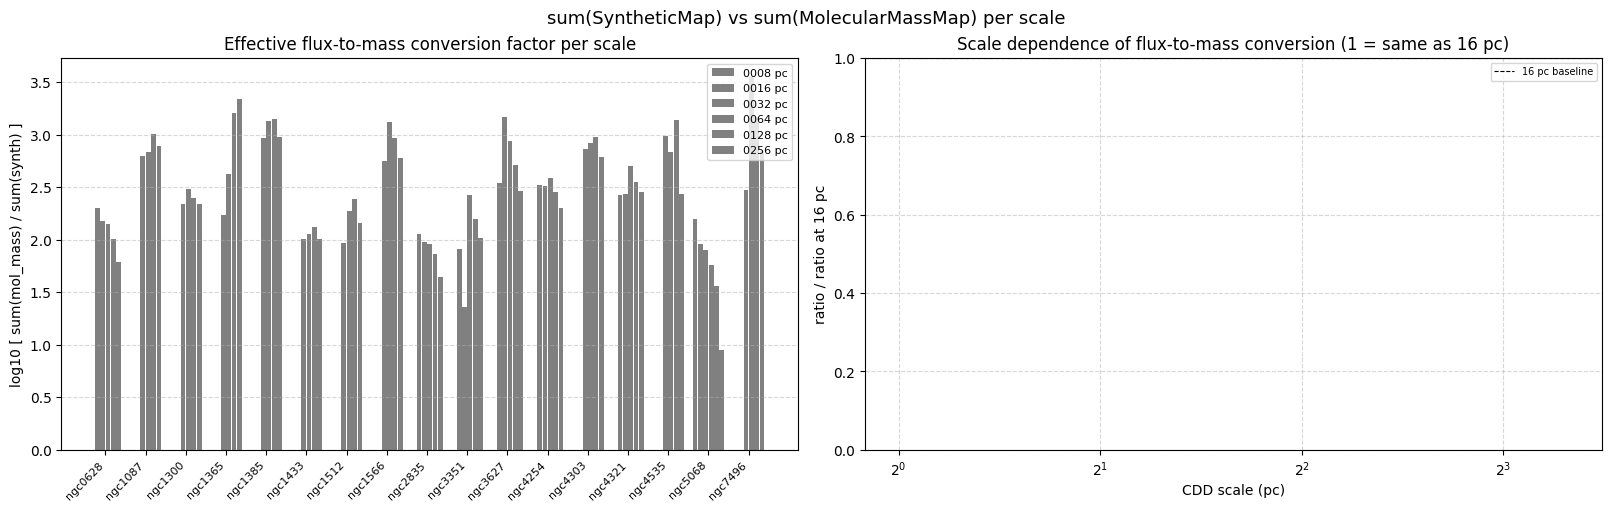

Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\SynthVsMolMass_ByScale.png


In [4]:
# =============================================================================
# Cell 4: sum(synth) vs sum(Molecular Mass map) per galaxy per scale
# =============================================================================
import re as _re

# SCALE_COLORS may already be defined by Cell 3; define here as fallback
if "SCALE_COLORS" not in dir():
    SCALE_COLORS = {"16": "#e41a1c", "32": "#ff7f00", "64": "#4daf4a",
                    "128": "#377eb8", "256": "#984ea3"}

results2 = {}

for gal_dir in galaxy_dirs:
    gal_name  = gal_dir.name
    synth_dir = gal_dir / "SyntheticMap"
    mass_dir  = gal_dir / "Molecular_Mass"

    if not mass_dir.is_dir():
        print(f"  [{gal_name}] no Molecular_Mass folder -- skipping")
        continue

    print()
    print(gal_name)
    print(f"  {'Scale':>5}  {'sum(synth)':>14}  {'sum(mol_mass)':>15}  {'ratio M/F':>12}")

    results2[gal_name] = {}

    for synth_file in sorted(synth_dir.glob("*_SyntheticMap_*.fits")):
        m = _re.search(r'CDDss(\d+)pc', synth_file.name)
        if not m:
            continue
        scale_str = m.group(1)

        cdd_tag = f"CDDss{int(scale_str):04d}pc"
        mass_candidates = [
            f for f in mass_dir.glob(f"*{cdd_tag}*MolecularMassMap*.fits")
            if ".fits_" not in f.name
        ]
        if not mass_candidates:
            mass_candidates = list(mass_dir.glob(f"*{cdd_tag}*MolecularMassMap*.fits"))
        if not mass_candidates:
            print(f"  {scale_str:>5}pc  -- molecular mass map not found")
            continue
        mass_file = sorted(mass_candidates)[-1]

        with fits.open(synth_file) as h:
            synth_data = np.array(h[0].data, dtype=float)
        with fits.open(mass_file) as h:
            mass_data = np.array(h[0].data, dtype=float)

        sum_synth = float(np.nansum(synth_data))
        sum_mass  = float(np.nansum(mass_data))
        ratio     = sum_mass / sum_synth if sum_synth != 0 else np.nan

        print(f"  {scale_str:>5}pc  {sum_synth:>14.4e}  {sum_mass:>15.4e}  {ratio:>12.4e}")
        results2[gal_name][scale_str] = (sum_synth, sum_mass, ratio)

print()
print("Done.")

# -- Plot: ratio and normalised ratio per scale per galaxy ------------------
gals2   = [g for g in results2 if results2[g]]
scales2 = sorted({s for g in gals2 for s in results2[g]}, key=float)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

ax = axes[0]
x = np.arange(len(gals2))
width = 0.8 / max(len(scales2), 1)
for i, s in enumerate(scales2):
    raw = [results2[g][s][2] if s in results2[g] else np.nan for g in gals2]
    valid = np.array(raw, dtype=float)
    valid[valid <= 0] = np.nan
    offset = (i - len(scales2) / 2 + 0.5) * width
    ax.bar(x + offset, np.log10(valid),
           width=width * 0.9, color=SCALE_COLORS.get(s, "gray"), label=f"{s} pc")
ax.set_xticks(x)
ax.set_xticklabels([g.replace("_F770W", "") for g in gals2],
                    rotation=45, ha="right", fontsize=8)
ax.set_ylabel("log10 [ sum(mol_mass) / sum(synth) ]")
ax.set_title("Effective flux-to-mass conversion factor per scale")
ax.legend(fontsize=8)
ax.grid(True, ls="--", alpha=0.5, axis="y")

ax2 = axes[1]
for g in gals2:
    ref = results2[g].get("16", (None, None, None))[2]
    if ref is None or not np.isfinite(ref) or ref <= 0:
        print(f"  {g}: no 16 pc reference -- skipping normalised plot")
        continue
    xs, ys = [], []
    for s in scales2:
        if s in results2[g] and np.isfinite(results2[g][s][2]):
            xs.append(float(s))
            ys.append(results2[g][s][2] / ref)
    if xs:
        ax2.plot(xs, ys, marker="o", lw=1.5, alpha=0.7,
                 label=g.replace("_F770W", ""))
ax2.axhline(1.0, color="k", ls="--", lw=0.8, label="16 pc baseline")
ax2.set_xscale("log", base=2)
ax2.set_xlabel("CDD scale (pc)")
ax2.set_ylabel("ratio / ratio at 16 pc")
ax2.set_title("Scale dependence of flux-to-mass conversion (1 = same as 16 pc)")
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, ls="--", alpha=0.5)

fig.suptitle("sum(SyntheticMap) vs sum(MolecularMassMap) per scale", fontsize=13)
out2 = BASE_DIR / "Figures" / "SynthVsMolMass_ByScale.png"
fig.savefig(out2, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {out2}")


ngc0628_F770W
  Scale   sum(synth_mass)    sum(csv_raw)   ratio S/C
   0016pc        3.6348e+08      6.1463e+08      0.5914
   0032pc        2.9923e+08      2.4949e+08      1.1994
   0064pc        2.8093e+08      6.5450e+07      4.2923
   0128pc        1.9577e+08      1.4038e+07     13.9453
   0256pc        1.0038e+08      2.8674e+06     35.0066

ngc1087_F770W
  Scale   sum(synth_mass)    sum(csv_raw)   ratio S/C
   0032pc        1.4412e+08      3.8084e+08      0.3784
   0064pc        1.2790e+08      1.1846e+08      1.0797
   0128pc        2.0533e+08      7.1797e+07      2.8599
   0256pc        1.6024e+08      1.5309e+07     10.4673

ngc1300_F770W
  Scale   sum(synth_mass)    sum(csv_raw)   ratio S/C
   0032pc        4.7622e+07      1.0075e+08      0.4727
   0064pc        4.6313e+07      4.4091e+07      1.0504
   0128pc        3.7888e+07      9.3204e+06      4.0650
   0256pc        2.5146e+07      1.9751e+06     12.7318

ngc1365_F770W
  Scale   sum(synth_mass)    sum(csv_raw)   ratio 

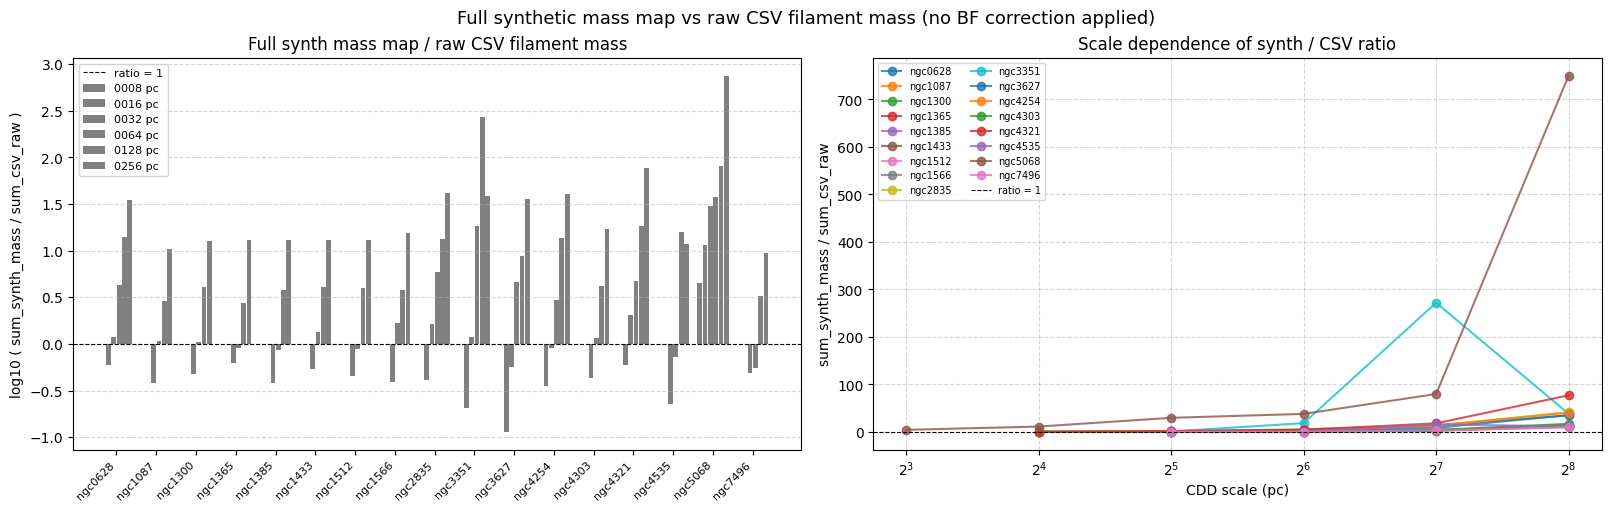

Saved C:\Users\jhoffm72\Documents\FilPHANGS\Data\Figures\SynthMassVsCSVMass.png


In [5]:
# =============================================================================
# Cell 5: Full synthetic mass map vs CSV filament mass -- all galaxies & scales
# Copies flux_toCo_21 and getMolecularMass logic from FilamentMap.py, applies
# them to each saved SyntheticMap FITS to compute total mass, then compares
# to the raw (un-BF-corrected) sum of Mass_{scale} in the CSV files.
# Displays ratio  sum(synth_mass) / sum(csv_mass_raw)  per galaxy per scale.
# =============================================================================
import re as _re2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from reproject import reproject_interp

CSV_PATH = Path(r"C:\Users\jhoffm72\Documents\FilPHANGS\Data\ImageData.xlsx")

# -- Replicated from FilamentMap.flux_toCo_21 ---------------------------------
def flux_toCo_21(I_F770W, sSFR, inclination_deg):
    inclination = inclination_deg * np.pi / 180
    I = I_F770W * np.cos(inclination)
    log_C = -0.21 * (np.log10(sSFR) + 10.14)
    valid = I > 0
    x = np.zeros_like(I)
    x[valid] = np.log(I[valid]) - log_C
    I_CO = np.zeros_like(I)
    I_CO[valid] = 10 ** (0.88 * (x[valid] - 1.44) + 1.36)
    return I_CO

# -- Replicated from FilamentMap.getMolecularMass (dynamic alphaCO path) ------
def get_molecular_mass(I_CO, synth_header, synth_shape,
                       alphaCO_dir, alphaCO_tag, galaxy_label):
    galaxy = galaxy_label.split("_")[0].lower()
    for fname in alphaCO_dir.iterdir():
        if galaxy in fname.name.lower() and alphaCO_tag.lower() in fname.name.lower():
            with fits.open(fname) as h:
                aco_data, aco_header = np.array(h[0].data, dtype=float), h[0].header
            aco_rep, _ = reproject_interp(
                (aco_data, aco_header), synth_header, shape_out=synth_shape
            )
            aco_rep = np.nan_to_num(aco_rep, nan=5.5)
            return aco_rep * I_CO
    return 5.5 * I_CO   # fallback constant alphaCO

# -- Read galaxy metadata (sSFR, inclination, min_power) from catalogue -------
_cat = pd.read_excel(CSV_PATH)

def get_galaxy_meta(galaxy_label):
    parts = galaxy_label.rsplit("_", 1)
    if len(parts) < 2:
        return None
    name, band = parts
    row = _cat[
        (_cat["label"].str.strip().str.lower() == name.lower()) &
        (_cat["Band"].str.strip().str.lower()  == band.lower())
    ]
    if row.empty:
        return None
    r = row.iloc[0]
    return float(r["SSFR"]), float(r["Inclination Angle"]), int(r["Power of 2 min"])

# -- Main loop ----------------------------------------------------------------
results3 = {}   # [galaxy][scale] = (sum_synth_mass, sum_csv_raw, ratio)

for gal_dir in galaxy_dirs:
    gal_name  = gal_dir.name
    synth_dir = gal_dir / "SyntheticMap"

    meta = get_galaxy_meta(gal_name)
    if meta is None:
        print(f"  [{gal_name}] not in catalogue -- skipping")
        continue
    sSFR, incl_deg, min_power = meta

    print()
    print(gal_name)
    print(f"  {'Scale':>5}  {'sum(synth_mass)':>16}  {'sum(csv_raw)':>14}  {'ratio S/C':>10}")

    results3[gal_name] = {}
    _aco_cache = {}   # reproject alphaCO once per synth shape

    for synth_file in sorted(synth_dir.glob("*_SyntheticMap_*.fits")):
        m = _re2.search(r'CDDss(\d+)pc', synth_file.name)
        if not m:
            continue
        scale_str = m.group(1)
        scale_int = int(scale_str)

        # matching CSV -- raw pipeline output, no BF correction
        cdd_tag     = f"CDDss{scale_int:04d}pc"
        csv_matches = sorted(synth_dir.glob(f"*{cdd_tag}*DensityData*.csv"))
        if not csv_matches:
            print(f"  {scale_str:>5}pc  -- CSV not found")
            continue
        df_csv   = pd.read_csv(csv_matches[-1])
        mass_col = f"Mass_{scale_int}.0"
        if mass_col not in df_csv.columns:
            print(f"  {scale_str:>5}pc  -- column {mass_col} missing")
            continue
        sum_csv_raw = float(df_csv[mass_col].dropna().sum())

        # load synthetic map FITS and run full mass conversion
        with fits.open(synth_file) as h:
            synth_data   = np.nan_to_num(np.array(h[0].data, dtype=float))
            synth_header = h[0].header

        I_CO     = flux_toCo_21(synth_data, sSFR, incl_deg)
        shape_key = synth_data.shape
        if shape_key not in _aco_cache:
            _aco_cache[shape_key] = get_molecular_mass(
                np.ones(shape_key), synth_header, shape_key,
                ALPHACO_DIR, ALPHACO_TAG, gal_name
            )  # store alphaCO map (ones * alphaCO = alphaCO)
        alphaCO_map  = _aco_cache[shape_key]
        mass_map     = alphaCO_map * I_CO
        sum_synth_mass = float(np.nansum(mass_map))

        ratio = sum_synth_mass / sum_csv_raw if sum_csv_raw != 0 else np.nan
        print(f"  {scale_str:>5}pc  {sum_synth_mass:>16.4e}  {sum_csv_raw:>14.4e}  {ratio:>10.4f}")
        results3[gal_name][scale_str] = (sum_synth_mass, sum_csv_raw, ratio)

print()
print("Done.")

# -- Plot ---------------------------------------------------------------------
if "SCALE_COLORS" not in dir():
    SCALE_COLORS = {"16": "#e41a1c", "32": "#ff7f00", "64": "#4daf4a",
                    "128": "#377eb8", "256": "#984ea3"}

gals3   = [g for g in results3 if results3[g]]
scales3 = sorted({s for g in gals3 for s in results3[g]}, key=float)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

# Left: log10(ratio) per galaxy per scale as grouped bars
ax = axes[0]
x = np.arange(len(gals3))
width = 0.8 / max(len(scales3), 1)
for i, s in enumerate(scales3):
    vals = np.array(
        [results3[g][s][2] if s in results3[g] else np.nan for g in gals3],
        dtype=float)
    vals[vals <= 0] = np.nan
    offset = (i - len(scales3) / 2 + 0.5) * width
    ax.bar(x + offset, np.log10(vals),
           width=width * 0.9, color=SCALE_COLORS.get(s, "gray"), label=f"{s} pc")
ax.axhline(0, color="k", lw=0.8, ls="--", label="ratio = 1")
ax.set_xticks(x)
ax.set_xticklabels([g.replace("_F770W", "") for g in gals3],
                    rotation=45, ha="right", fontsize=8)
ax.set_ylabel("log10 ( sum_synth_mass / sum_csv_raw )")
ax.set_title("Full synth mass map / raw CSV filament mass")
ax.legend(fontsize=8)
ax.grid(True, ls="--", alpha=0.5, axis="y")

# Right: ratio vs scale, one line per galaxy
ax2 = axes[1]
for g in gals3:
    xs, ys = [], []
    for s in sorted(results3[g], key=float):
        r = results3[g][s][2]
        if np.isfinite(r) and r > 0:
            xs.append(float(s))
            ys.append(r)
    if xs:
        ax2.plot(xs, ys, marker="o", lw=1.5, alpha=0.8,
                 label=g.replace("_F770W", ""))
ax2.axhline(1.0, color="k", ls="--", lw=0.8, label="ratio = 1")
ax2.set_xscale("log", base=2)
ax2.set_xlabel("CDD scale (pc)")
ax2.set_ylabel("sum_synth_mass / sum_csv_raw")
ax2.set_title("Scale dependence of synth / CSV ratio")
ax2.legend(fontsize=7, ncol=2)
ax2.grid(True, ls="--", alpha=0.5)

fig.suptitle(
    "Full synthetic mass map vs raw CSV filament mass (no BF correction applied)",
    fontsize=13)
out3 = BASE_DIR / "Figures" / "SynthMassVsCSVMass.png"
fig.savefig(out3, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved {out3}")